# Aluminium smelting emissions

All sixteen runs, laid out the same way in every figure: carbon capture regime down the rows,
GCAM ambition scenario (SSP-RCP pair) across the columns. Each ambition scenario carries its own
GCAM demand, grid and carbon budget, so the budget line differs by column. The caption under each
figure explains both axes.

Loading, the run registry, colours and the layout helpers live in `../../common.py`;
`run_name(ambition, ccs)` builds a cell name. Interim stand-in GCAM runs.

In [1]:
import sys
import importlib
sys.path.append("../..")

import common
importlib.reload(common)   # pick up edits to common.py without restarting the kernel

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from common import (RUNS_INDEX, CCS_ORDER, CCS_LABELS, GRIDS, GRID_LABELS,
                    GRID_COLOURS, CAPTION, run_name, style, emissions, budget, production,
                    production_by_technology, intensity_split, process_emission_factors,
                    power_source, capture_grid, label_rows, add_caption, overlaid, year_axis, save)

style()
pd.set_option("display.width", 250)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
ALL = list(RUNS_INDEX)
smelter = {n: emissions(n, "smelter") for n in ALL}
budgets = {n: budget("smelter", n) for n in ALL}                 # per-scenario GCAM budget, Mt/yr
cumulative = {n: s.cumsum() / 1000 for n, s in smelter.items()}  # Gt
budget_cum = {n: b.cumsum() / 1000 for n, b in budgets.items()}  # Gt
print(f"loaded {len(ALL)} runs")

loaded 16 runs


## Annual emissions against the carbon budget

wrote figures/smelting_emissions_annual.png and .svg


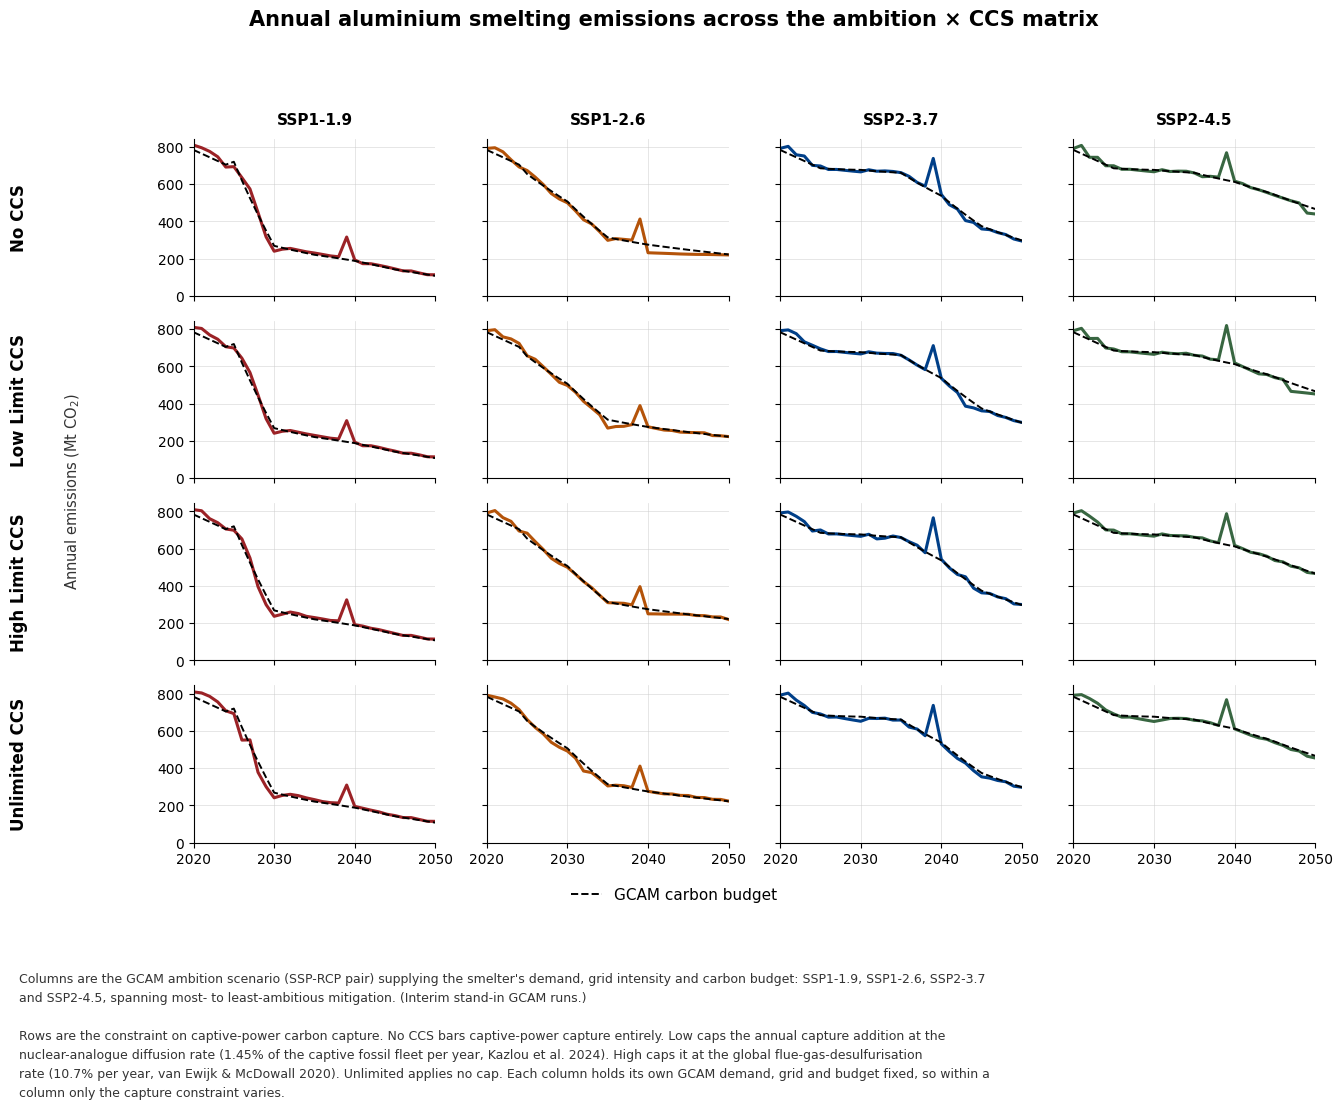

In [3]:
fig, axes = capture_grid(figsize=(13.5, 11.2))
for ccs in CCS_ORDER:
    for grid in GRIDS:
        n = run_name(grid, ccs)
        ax = axes[(ccs, grid)]
        series = smelter[n]
        lim = budgets[n]
        ax.plot(series.index, series.values, color=GRID_COLOURS[grid], lw=2.2, label="Scenario")
        ax.plot(lim.index, lim.values, "k--", lw=1.4, label="GCAM carbon budget")
        ax.set_ylim(bottom=0)
handles, labels = axes[(CCS_ORDER[0], GRIDS[0])].get_legend_handles_labels()
fig.legend(handles[1:], labels[1:], loc="lower center", ncol=1, frameon=False,
           fontsize=11, bbox_to_anchor=(0.5, 0.175))
fig.suptitle("Annual aluminium smelting emissions across the ambition \u00d7 CCS matrix",
             fontsize=15, fontweight="bold", y=0.985)
fig.tight_layout(rect=[0.105, 0.205, 1, 0.94])
label_rows(axes, "Annual emissions (Mt CO$_2$)")
add_caption(fig, y=0.012)
save(fig, "smelting_emissions_annual")
plt.show()

## Cumulative emissions against the carbon budget

Shading is the overshoot.

wrote figures/smelting_emissions_cumulative.png and .svg


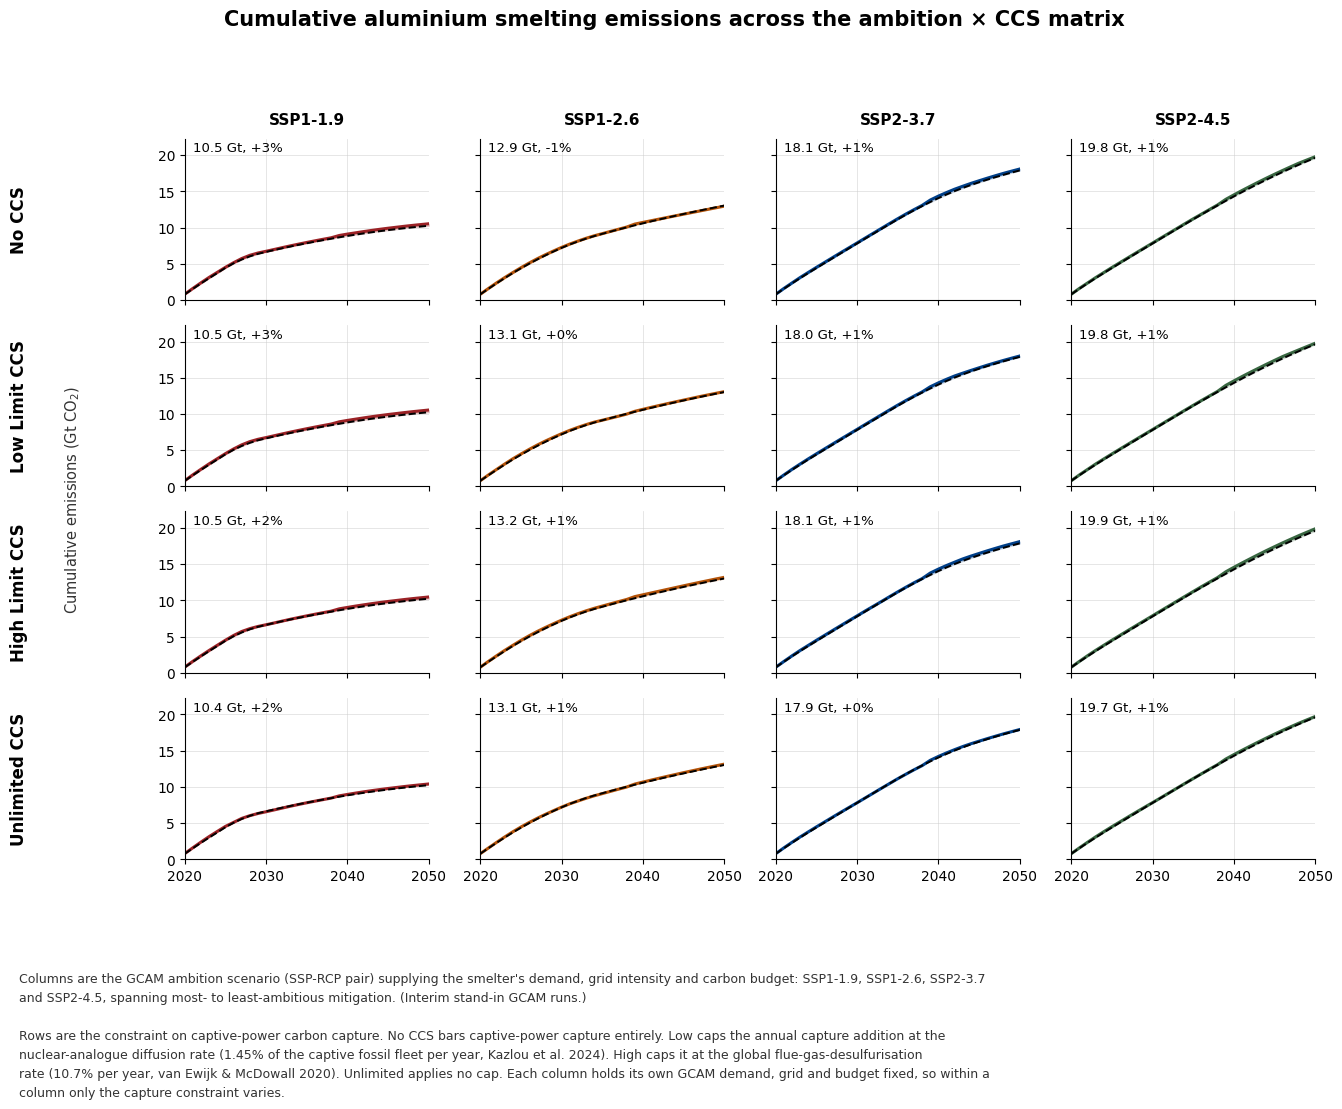

In [4]:
fig, axes = capture_grid(figsize=(13.5, 11.2))
ymax = max(v.loc[2050] for v in cumulative.values()) * 1.12
for ccs in CCS_ORDER:
    for grid in GRIDS:
        n = run_name(grid, ccs)
        ax = axes[(ccs, grid)]
        series = cumulative[n]
        bcum = budget_cum[n]
        ax.plot(series.index, series.values, color=GRID_COLOURS[grid], lw=2.2)
        ax.plot(bcum.index, bcum.values, "k--", lw=1.4)
        ax.fill_between(series.index, bcum.values, series.values,
                        where=series.values > bcum.values,
                        color=GRID_COLOURS[grid], alpha=0.18)
        over = 100 * (series.loc[2050] / bcum.loc[2050] - 1)
        ax.text(2021, 0.92 * ymax, f"{series.loc[2050]:.1f} Gt, {over:+.0f}%", fontsize=9.5)
        ax.set_ylim(0, ymax)
fig.suptitle("Cumulative aluminium smelting emissions across the ambition \u00d7 CCS matrix",
             fontsize=15, fontweight="bold", y=0.985)
fig.tight_layout(rect=[0.105, 0.19, 1, 0.94])
label_rows(axes, "Cumulative emissions (Gt CO$_2$)")
add_caption(fig, y=0.012)
save(fig, "smelting_emissions_cumulative")
plt.show()

## Summary

In [5]:
rows = []
for ccs in CCS_ORDER:
    for grid in GRIDS:
        n = run_name(grid, ccs)
        rows.append({"CCS regime": CCS_LABELS[ccs].replace("\n", " "), "Ambition": GRID_LABELS[grid],
                     "Smelting Gt": smelter[n].sum() / 1000,
                     "vs budget %": 100 * (smelter[n].sum() / budgets[n].sum() - 1)})
pd.DataFrame(rows)

,CCS regime,Ambition,Smelting Gt,vs budget %
0,No CCS,SSP1-1.9,10.52,2.70
1,No CCS,SSP1-2.6,12.95,-0.62
2,No CCS,SSP2-3.7,18.07,1.11
3,No CCS,SSP2-4.5,19.77,0.79
4,Low Limit CCS,SSP1-1.9,10.55,2.98
5,Low Limit CCS,SSP1-2.6,13.08,0.44
6,Low Limit CCS,SSP2-3.7,18.00,0.71
7,Low Limit CCS,SSP2-4.5,19.76,0.76
8,High Limit CCS,SSP1-1.9,10.48,2.35
9,High Limit CCS,SSP1-2.6,13.19,1.27
